In [37]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [42]:
preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-24_05-18-42_resnet_vanilla/preds_5000.h5"

with h5py.File(preds_file, "r") as f:
    print(f.keys())
    print(f["fiducial"].keys())
    
    indices = f["fiducial"]["indices"][:]
    
    grid_preds = f["grid/preds"][:]
    fid_preds = f["fiducial/preds"][:]
    
print(grid_preds.shape)
print(fid_preds.shape)

<KeysViewHDF5 ['fiducial', 'grid']>
<KeysViewHDF5 ['indices', 'preds']>
(2499, 16, 4)
(800, 4)


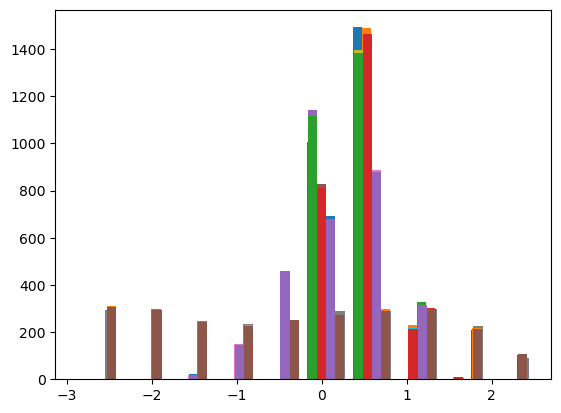

In [15]:
for i in range(4):
    plt.hist(grid_preds[:,i])

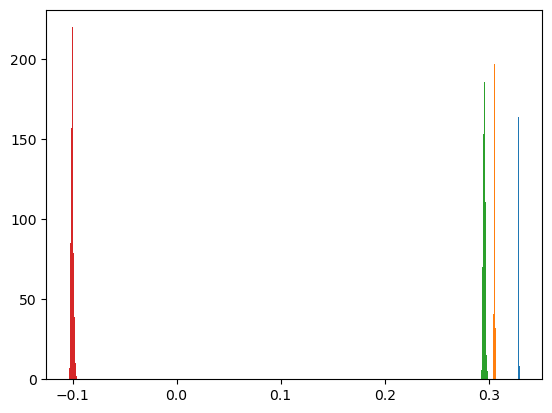

In [16]:
for i in range(4):
    plt.hist(fid_preds[:,i])

In [16]:
preds_file = "/pscratch/sd/a/athomsen/run_files/2023-03-13_06-27-46_resnet_small/preds.h5"

with h5py.File(evals_file, "r") as f:
    print(f.keys())
    
    preds = f["preds"][:]
    cosmos = f["cosmos"][:]
    sobols = f["sobols"][:]
    
print(cosmos.shape)
print(preds.shape)
print(sobols.shape)

<KeysViewHDF5 ['cosmos', 'noises', 'preds', 'sobols']>
(2500, 16, 7)
(2500, 16, 2)
(2500, 16)


In [17]:
np.transpose(cosmos, [1,0,2]).shape

NameError: name 'np' is not defined

In [1]:
import yaml

In [33]:
with open("/pscratch/sd/a/athomsen/run_files/v3/2023-05-24_06-39-40_resnet_vanilla/configs.yaml", "r") as f:
    net_conf, dlss_conf, msfm_conf = list(yaml.load_all(f, Loader=yaml.FullLoader))


In [35]:
dlss_conf

{'delta_loss': {'cov_weight': False,
  'eps': 1e-32,
  'force_params_value': 0.0,
  'force_params_weight': 1.0,
  'jac_cond_weight': None,
  'jac_weight': 100.0,
  'tikhonov_regu': False,
  'use_log_det': True},
 'dirs': {'base': 'run_files'},
 'dset': {'eval': {'fiducial': {'params': []},
   'grid': {'params': ['Om', 's8']}},
  'general': {'apply_norm': True,
   'with_clustering': False,
   'with_lensing': True},
  'training': {'params': ['Om', 's8']}},
 'inference': {'abc': {'kernel_min_val': 1e-42}, 'gaussian_process': None}}

In [30]:
net_conf, dlss_conf, msfm_conf = configs

In [32]:
net_conf

{'dset': {'eval': {'fiducial': {'i_noise': 2,
    'is_cached': False,
    'is_eval': True,
    'local_batch_size': 100,
    'n_prefetch': None,
    'n_readers': 16},
   'grid': {'local_batch_size': 100, 'n_prefetch': None, 'n_readers': 16}},
  'training': {'examples_shuffle_buffer': 64,
   'file_name_shuffle_buffer': 128,
   'is_cached': True,
   'local_batch_size': 8,
   'n_prefetch': None,
   'n_readers': 16}},
 'model': {'kwargs': {'n_base_channels': 32,
   'n_cheby': 2,
   'n_downsampling': 3,
   'n_residuals': 5,
   'poly_degree': 5},
  'max_checkpoints': 5,
  'n_neighbors': 20,
  'name': 'resnet'},
 'name': 'resnet_vanilla',
 'training': {'checkpoint_every': 5000,
  'clip_by_global_norm': 5.0,
  'clip_by_norm': None,
  'clip_by_value': None,
  'eval_every': 5000,
  'learning_rate': 0.001,
  'n_steps': 20000,
  'output_every': None}}

In [45]:
import os